In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("data/application_train.csv")

In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.shape

(307511, 122)

In [8]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

In [9]:
df.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE                str
CODE_GENDER                       str
FLAG_OWN_CAR                      str
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [10]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [11]:
missing = df.isnull().sum()

missing.sort_values(ascending=False).head(20)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_AVG                182590
LANDAREA_MODE               182590
dtype: int64

In [12]:
df.groupby("TARGET")["AMT_INCOME_TOTAL"].mean()

TARGET
0    169077.722266
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64

In [13]:
df.groupby("TARGET")["AMT_CREDIT"].mean()

TARGET
0    602648.282002
1    557778.527674
Name: AMT_CREDIT, dtype: float64

In [14]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False).head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

In [15]:
cols_to_drop = missing_percent[missing_percent > 70].index

df.drop(columns=cols_to_drop, inplace=True)

In [16]:
df.shape

(307511, 122)

In [18]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns

In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [20]:
print(len(num_cols))
print(len(cat_cols))

106
16


In [22]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [24]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [25]:
df.isnull().sum().sum()

np.int64(0)

In [26]:
[id_col for id_col in df.columns if 'ID' in id_col]

['SK_ID_CURR', 'DAYS_ID_PUBLISH']

In [27]:
df.drop(columns=["SK_ID_CURR"], inplace=True)

In [28]:
df_encoded = pd.get_dummies(df)

In [29]:
X = df_encoded.drop(columns=["TARGET"])

y = df_encoded["TARGET"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
preds = model.predict(X_test)

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.67      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.79      0.50      0.48     61503
weighted avg       0.90      0.92      0.88     61503



In [35]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False).head(20)

,Feature,Importance
28,EXT_SOURCE_2,0.049782
29,EXT_SOURCE_3,0.047718
6,DAYS_BIRTH,0.033186
9,DAYS_ID_PUBLISH,0.032903
8,DAYS_REGISTRATION,0.032123
3,AMT_ANNUITY,0.029599
77,DAYS_LAST_PHONE_CHANGE,0.028580
7,DAYS_EMPLOYED,0.028237
2,AMT_CREDIT,0.027935
1,AMT_INCOME_TOTAL,0.024952


In [ ]:
# top risk indicators, interesting patterns, anomalies, business implications

In [36]:
df_encoded.to_csv("data/cleaned_application_train.csv", index=False)

In [61]:
# ANOMALY DETECTION ENGINE

In [37]:
high_credit = df[df["AMT_CREDIT"] > 2000000]

high_credit.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
189,0,Cash loans,M,N,Y,1,315000.0,2250000.0,83515.5,2250000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
341,0,Cash loans,M,Y,Y,2,405000.0,2250000.0,59485.5,2250000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
485,0,Cash loans,F,Y,Y,0,450000.0,2286211.5,116266.5,2182500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
748,0,Cash loans,M,N,N,0,306000.0,2085120.0,72477.0,1800000.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,4.0
871,0,Cash loans,M,Y,N,0,450000.0,2125953.0,81108.0,1984500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
low_income = df[df["AMT_INCOME_TOTAL"] < 30000]

low_income.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
1678,0,Cash loans,F,N,N,0,25650.0,158148.0,5809.5,103500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
2375,0,Cash loans,F,N,Y,0,29250.0,152820.0,10080.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
3119,0,Cash loans,F,Y,N,1,27000.0,101880.0,10075.5,90000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4606,0,Cash loans,F,N,Y,1,27000.0,112500.0,5409.0,112500.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
4735,0,Cash loans,M,N,Y,0,27000.0,284400.0,9211.5,225000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
risky_customers = df[
    (df["AMT_CREDIT"] > 1000000) &
    (df["AMT_INCOME_TOTAL"] < 50000)
]

risky_customers.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
3836,0,Cash loans,F,N,N,0,45000.0,1097131.5,43510.5,886500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4265,0,Cash loans,F,N,Y,0,45000.0,1125000.0,33025.5,1125000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
16784,0,Cash loans,F,N,N,1,40500.0,1305000.0,38155.5,1305000.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
20727,1,Cash loans,F,Y,Y,0,25650.0,2173500.0,48118.5,2173500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
22424,0,Cash loans,F,N,N,0,49500.0,1125000.0,31702.5,1125000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
len(risky_customers)

58

In [41]:
risky_customers.to_csv(
    "data/threshold_anomalies.csv",
    index=False
)

In [ ]:
# ZSCORE DETECTION

In [ ]:
from scipy.stats import zscore

In [ ]:
df["credit_zscore"] = zscore(df["AMT_CREDIT"])

In [ ]:
credit_anomalies = df[
    abs(df["credit_zscore"]) > 3
]

credit_anomalies.head()

In [ ]:
len(credit_anomalies)

In [ ]:
credit_anomalies[
    [
        "AMT_CREDIT",
        "AMT_INCOME_TOTAL"
    ]
].describe()

In [ ]:
credit_anomalies.to_csv(
    "data/zscore_anomalies.csv",
    index=False
)

In [ ]:
# MACHINE LEARNING ANOMALY DETECTION

In [48]:
from sklearn.ensemble import IsolationForest

In [44]:
features = df[
    [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "DAYS_EMPLOYED"
    ]
    ]

In [46]:
features = features.fillna(features.median())

In [49]:
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

In [51]:
iso.fit(features)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [53]:
df["anomaly"] = iso.predict(features)
df = df.copy()

In [54]:
ml_anomalies = df[df["anomaly"] == -1]

ml_anomalies.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,anomaly
319,0,Revolving loans,M,Y,Y,0,765000.0,1350000.0,67500.0,1350000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,-1
341,0,Cash loans,M,Y,Y,2,405000.0,2250000.0,59485.5,2250000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,-1
391,0,Revolving loans,M,Y,Y,3,607500.0,1350000.0,67500.0,1350000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,-1
441,0,Cash loans,F,Y,Y,0,450000.0,1971072.0,62019.0,1800000.0,...,0,0,0,0.0,0.0,0.0,0.0,4.0,1.0,-1
485,0,Cash loans,F,Y,Y,0,450000.0,2286211.5,116266.5,2182500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,-1


In [55]:
len(ml_anomalies)

3073

In [56]:
ml_anomalies[
    [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "DAYS_EMPLOYED"
    ]
].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,DAYS_EMPLOYED
count,3.073000e+03,3.073000e+03,3073.000000
mean,5.960915e+05,1.679561e+06,164572.012366
std,2.179318e+06,6.180460e+05,183734.441313
min,2.565000e+04,4.500000e+04,-15516.000000
25%,3.375000e+05,1.350000e+06,-2992.000000
50%,4.500000e+05,1.762110e+06,-347.000000
75%,6.750000e+05,2.115000e+06,365243.000000
max,1.170000e+08,4.050000e+06,365243.000000


In [57]:
ml_anomalies.to_csv(
    "data/ml_anomalies.csv",
    index=False
)

In [58]:
# VISUALISATION

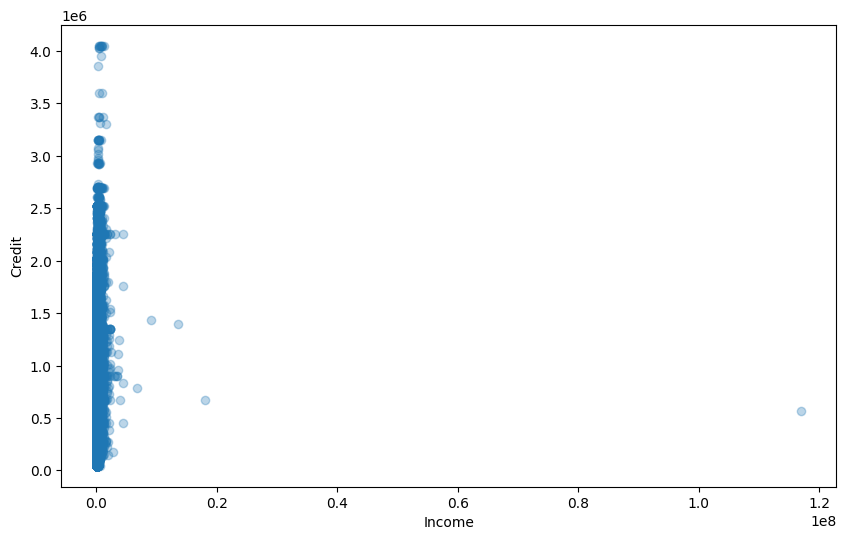

In [59]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["AMT_INCOME_TOTAL"],
    df["AMT_CREDIT"],
    alpha=0.3
)

plt.xlabel("Income")
plt.ylabel("Credit")

plt.show()

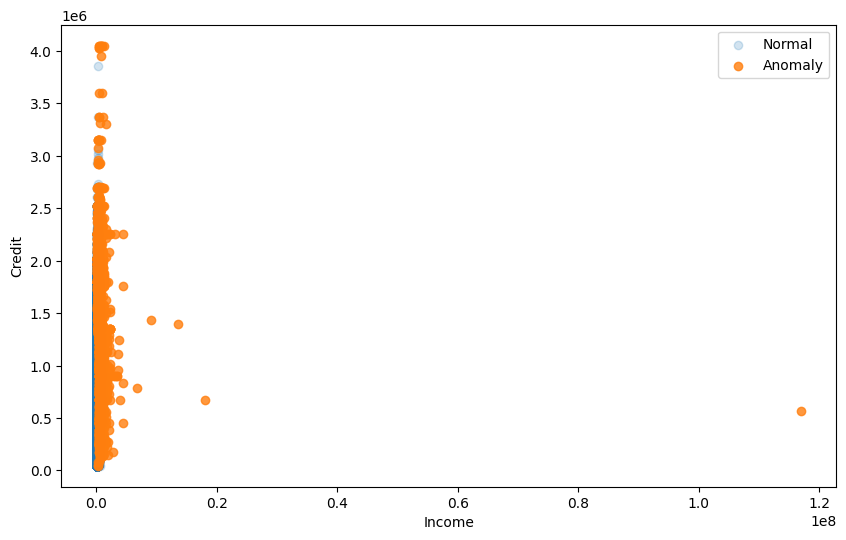

In [60]:
plt.figure(figsize=(10,6))

normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

plt.scatter(
    normal["AMT_INCOME_TOTAL"],
    normal["AMT_CREDIT"],
    alpha=0.2,
    label="Normal"
)

plt.scatter(
    anomaly["AMT_INCOME_TOTAL"],
    anomaly["AMT_CREDIT"],
    alpha=0.8,
    label="Anomaly"
)

plt.xlabel("Income")
plt.ylabel("Credit")

plt.legend()

plt.show()

In [ ]:
# ROOT CAUSE ANALYSIS

In [62]:
ml_anomalies[
    [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "DAYS_EMPLOYED",
        "TARGET"
    ]
].head()

,AMT_INCOME_TOTAL,AMT_CREDIT,DAYS_EMPLOYED,TARGET
319,765000.0,1350000.0,-3144,0
341,405000.0,2250000.0,-6158,0
391,607500.0,1350000.0,-3269,0
441,450000.0,1971072.0,-2569,0
485,450000.0,2286211.5,-13994,0


In [63]:
normal.describe()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,anomaly
count,304438.000000,304438.000000,3.044380e+05,3.044380e+05,304438.000000,3.044380e+05,304438.000000,304438.000000,304438.000000,304438.000000,...,304438.000000,304438.000000,304438.000000,304438.000000,304438.000000,304438.000000,304438.000000,304438.000000,304438.000000,304438.0
mean,0.081130,0.418243,1.644848e+05,5.881191e+05,26765.227498,5.280502e+05,0.020753,-16014.314277,62798.004149,-4984.445526,...,0.000581,0.000499,0.000335,0.005554,0.006050,0.029750,0.229955,0.229439,1.780284,1.0
std,0.273035,0.722756,8.371415e+04,3.845455e+05,13866.964293,3.518421e+05,0.013655,4362.826793,140414.214277,3519.827976,...,0.024105,0.022339,0.018301,0.078156,0.102666,0.190978,0.852267,0.745382,1.765366,0.0
min,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25201.000000,-17912.000000,-24672.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,0.000000,0.000000,1.125000e+05,2.700000e+05,16456.500000,2.385000e+05,0.010006,-19649.750000,-2759.000000,-7476.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0
50%,0.000000,0.000000,1.440000e+05,5.085000e+05,24750.000000,4.500000e+05,0.018850,-15719.000000,-1218.000000,-4503.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0
75%,0.000000,1.000000,2.025000e+05,8.086500e+05,34245.000000,6.795000e+05,0.028663,-12390.000000,-298.000000,-2012.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.0
max,1.000000,19.000000,1.350000e+06,3.860019e+06,225000.000000,3.555000e+06,0.072508,-7489.000000,365243.000000,0.000000,...,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000,1.0


In [64]:
anomaly.describe()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,anomaly
count,3073.000000,3073.000000,3.073000e+03,3.073000e+03,3073.000000,3.073000e+03,3073.000000,3073.000000,3073.000000,3073.000000,...,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.0
mean,0.041002,0.299056,5.960915e+05,1.679561e+06,61114.830947,1.555360e+06,0.032309,-18283.950537,164572.012366,-5152.040677,...,0.001952,0.001302,0.000325,0.003905,0.006508,0.027009,0.363814,0.248617,1.598113,-1.0
std,0.198328,0.645539,2.179318e+06,6.180460e+05,28327.285673,5.814555e+05,0.023227,3867.035039,183734.441313,3810.706479,...,0.044151,0.036061,0.018039,0.062378,0.134858,0.164133,1.219051,0.598407,1.772059,0.0
min,0.000000,0.000000,2.565000e+04,4.500000e+04,2749.500000,4.500000e+04,0.001276,-25229.000000,-15516.000000,-20560.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0
25%,0.000000,0.000000,3.375000e+05,1.350000e+06,46926.000000,1.237500e+06,0.011657,-21555.000000,-2992.000000,-7948.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0
50%,0.000000,0.000000,4.500000e+05,1.762110e+06,58333.500000,1.588500e+06,0.026392,-19233.000000,-347.000000,-4554.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-1.0
75%,0.000000,0.000000,6.750000e+05,2.115000e+06,68350.500000,1.845000e+06,0.046220,-15224.000000,365243.000000,-1798.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-1.0
max,1.000000,5.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-8312.000000,365243.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,6.000000,2.000000,22.000000,6.000000,17.000000,-1.0


In [65]:
comparison = pd.DataFrame({
    "Normal": normal.mean(numeric_only=True),
    "Anomaly": anomaly.mean(numeric_only=True)
})

comparison.head(20)

,Normal,Anomaly
TARGET,0.081130,4.100228e-02
CNT_CHILDREN,0.418243,2.990563e-01
AMT_INCOME_TOTAL,164484.813748,5.960915e+05
AMT_CREDIT,588119.070338,1.679561e+06
AMT_ANNUITY,26765.227498,6.111483e+04
AMT_GOODS_PRICE,528050.246674,1.555360e+06
REGION_POPULATION_RELATIVE,0.020753,3.230882e-02
DAYS_BIRTH,-16014.314277,-1.828395e+04
DAYS_EMPLOYED,62798.004149,1.645720e+05
DAYS_REGISTRATION,-4984.445526,-5.152041e+03


In [66]:
comparison["Difference"] = (
    comparison["Anomaly"] -
    comparison["Normal"]
)

comparison.sort_values(
    by="Difference",
    ascending=False
).head(20)

,Normal,Anomaly,Difference
AMT_CREDIT,588119.070338,1.679561e+06,1.091442e+06
AMT_GOODS_PRICE,528050.246674,1.555360e+06,1.027310e+06
AMT_INCOME_TOTAL,164484.813748,5.960915e+05,4.316067e+05
DAYS_EMPLOYED,62798.004149,1.645720e+05,1.017740e+05
AMT_ANNUITY,26765.227498,6.111483e+04,3.434960e+04
HOUR_APPR_PROCESS_START,12.055308,1.286691e+01,8.115968e-01
AMT_REQ_CREDIT_BUREAU_MON,0.229955,3.638139e-01,1.338590e-01
EXT_SOURCE_2,0.513569,6.070962e-01,9.352744e-02
FLAG_DOCUMENT_8,0.080598,1.584771e-01,7.787937e-02
FLOORSMAX_AVG,0.195923,2.670295e-01,7.110663e-02


In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

In [70]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
28,EXT_SOURCE_2,0.049782
29,EXT_SOURCE_3,0.047718
6,DAYS_BIRTH,0.033186
9,DAYS_ID_PUBLISH,0.032903
8,DAYS_REGISTRATION,0.032123
3,AMT_ANNUITY,0.029599
77,DAYS_LAST_PHONE_CHANGE,0.028580
7,DAYS_EMPLOYED,0.028237
2,AMT_CREDIT,0.027935
1,AMT_INCOME_TOTAL,0.024952


In [71]:
def generate_recommendation(row):

    if (
        row["AMT_CREDIT"] > 1000000 and
        row["AMT_INCOME_TOTAL"] < 50000
    ):
        return "High risk: reduce loan exposure"

    return "Normal"

In [75]:
anomaly["recommendation"] = anomaly.apply(
    generate_recommendation,
    axis=1
)

In [76]:
anomaly[
    [
        "AMT_CREDIT",
        "AMT_INCOME_TOTAL",
        "recommendation"
    ]
].head()

,AMT_CREDIT,AMT_INCOME_TOTAL,recommendation
319,1350000.0,765000.0,Normal
341,2250000.0,405000.0,Normal
391,1350000.0,607500.0,Normal
441,1971072.0,450000.0,Normal
485,2286211.5,450000.0,Normal


In [74]:
comparison.sort_values(
    by="Difference",
    ascending=False
).head(20)

,Normal,Anomaly,Difference
AMT_CREDIT,588119.070338,1.679561e+06,1.091442e+06
AMT_GOODS_PRICE,528050.246674,1.555360e+06,1.027310e+06
AMT_INCOME_TOTAL,164484.813748,5.960915e+05,4.316067e+05
DAYS_EMPLOYED,62798.004149,1.645720e+05,1.017740e+05
AMT_ANNUITY,26765.227498,6.111483e+04,3.434960e+04
HOUR_APPR_PROCESS_START,12.055308,1.286691e+01,8.115968e-01
AMT_REQ_CREDIT_BUREAU_MON,0.229955,3.638139e-01,1.338590e-01
EXT_SOURCE_2,0.513569,6.070962e-01,9.352744e-02
FLAG_DOCUMENT_8,0.080598,1.584771e-01,7.787937e-02
FLOORSMAX_AVG,0.195923,2.670295e-01,7.110663e-02


In [ ]:
# AI Risk Summary

# The anomaly engine identified customers with:

# - unusually high loan exposure
# - weak income stability
# - abnormal employment behavior

# These profiles indicate elevated repayment risk.

# Recommended actions:
# - tighten approval criteria
# - reduce exposure limits
# - increase verification requirements